# 03 RAGAS Answer Evaluation

Simple notebook-only answer evaluation. It loads RAGAS-generated benchmark questions, uses the method selected by notebook 02, generates or loads answers, and runs RAGAS answer metrics.

In [1]:

from pathlib import Path
import json
import math
import os
import sys
from collections import defaultdict

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib-cache"))

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import Dataset
from dotenv import load_dotenv
from IPython.display import Image, Markdown, display
from rank_bm25 import BM25Okapi
from ragas import evaluate
from sklearn.feature_extraction.text import TfidfVectorizer

from src.data.chunking import chunk_documents
from src.data.clean_text import normalize_for_match, tokenize_vi
from src.data.load_dataset import load_documents_from_jsonl
from src.data.schema import SearchResult

CORPUS_PATH = PROJECT_ROOT / "data/processed/labor_corpus.jsonl"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
RAGAS_QUESTIONS_JSON = REPORTS_DIR / "ragas_questions.json"
RETRIEVAL_JSON = REPORTS_DIR / "retrieval_evaluation.json"
RETRIEVAL_MD = REPORTS_DIR / "retrieval_evaluation.md"
RAG_ANSWERS_JSON = REPORTS_DIR / "rag_answers.json"
RAGAS_EVAL_JSON = REPORTS_DIR / "ragas_evaluation.json"
RAGAS_EVAL_MD = REPORTS_DIR / "ragas_evaluation.md"

DEFAULT_MODEL = "gemini-3.1-flash-lite"
DEFAULT_EMBEDDING_MODEL = "models/gemini-embedding-001"
EVALUATION_VERSION = "ragas_answer_eval_v2"
TOP_K = 5
BENCHMARK_MAX_CHUNKS = None
METHODS = ["bm25", "vector", "hybrid", "hybrid_rrf", "hybrid_rrf_mmr"]

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def gemini_keys():
    load_dotenv(PROJECT_ROOT / ".env")
    raw_values = [
        os.getenv("GOOGLE_API_KEY") or "",
        os.getenv("GEMINI_API_KEY") or "",
        os.getenv("GEMINI_API_KEYS") or "",
    ]
    keys, seen = [], set()
    for raw_value in raw_values:
        for key in raw_value.split(","):
            key = key.strip()
            if key and key not in seen:
                keys.append(key)
                seen.add(key)
    return keys


def load_ragas_questions():
    if not RAGAS_QUESTIONS_JSON.exists():
        raise FileNotFoundError("Missing reports/ragas_questions.json. Run the RAGAS TestsetGenerator cell first.")
    payload = json.loads(RAGAS_QUESTIONS_JSON.read_text(encoding="utf-8"))
    if not payload.get("generated_with_ragas"):
        raise ValueError("reports/ragas_questions.json must come from RAGAS TestsetGenerator.")
    items = payload.get("items") or []
    if len(items) < 30:
        raise ValueError("RAGAS benchmark must contain at least 30 accepted questions.")
    return payload, items



def sanitize(value):
    if isinstance(value, dict):
        return {key: sanitize(item) for key, item in value.items()}
    if isinstance(value, list):
        return [sanitize(item) for item in value]
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value

from ragas.run_config import RunConfig
from src.generation.gemini_client import BatchGeminiClient
from src.generation.prompt import build_rag_prompt

C:\Users\Acer Nitro\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load RAGAS Questions and Selected Retriever

In [2]:

question_meta, questions = load_ragas_questions()
retrieval_report = json.loads(RETRIEVAL_JSON.read_text(encoding="utf-8"))
selected_method = retrieval_report["selected_method"]
pd.DataFrame([{k: question_meta.get(k) for k in ["generated_with_ragas", "candidate_target", "accepted_count"]}])


,generated_with_ragas,candidate_target,accepted_count
0,True,40,30


In [3]:
pd.DataFrame(questions)[["id", "topic", "source", "question", "reference"]].head(10)

,id,topic,source,question,reference
0,ragas_001,single_hop_specific_query_synthesizer,ragas_generator,Theo quy định tại CHƯƠNG VI thì khi xí nghiệp ...,"Khi giải thể, xí nghiệp phải thực hiện các ngh..."
1,ragas_002,single_hop_specific_query_synthesizer,ragas_generator,Quy trình giải thể Xí nghiệp liên doanh được q...,Khi Xí nghiệp liên doanh hoạt động sản xuất ki...
2,ragas_003,single_hop_specific_query_synthesizer,ragas_generator,Khi nào thì hội đồng quản trị của xí nghiệp li...,"Theo quy định, Hội đồng quản trị Xí nghiệp liê..."
3,ragas_004,single_hop_specific_query_synthesizer,ragas_generator,CHƯƠNG VI nói về cái gì vậy ạ?,CHƯƠNG VI quy định về ĐIỀU KHOẢN THI HÀNH.
4,ragas_005,single_hop_specific_query_synthesizer,ragas_generator,anh oi cho hoi cai Nghị định số 103/1999/NĐ-CP...,"Theo quy định tại Nghị định số 103/1999/NĐ-CP,..."
5,ragas_006,single_hop_specific_query_synthesizer,ragas_generator,Theo Nghị định số 103/1999/NĐ-CP của Chính phủ...,"Các văn bản do người được giao, người mua, ngư..."
6,ragas_007,single_hop_specific_query_synthesizer,ragas_generator,Nghị định số 103/1999/NĐ-CP quy định gì về việ...,"Theo Nghị định số 103/1999/NĐ-CP, người được g..."
7,ragas_008,single_hop_specific_query_synthesizer,ragas_generator,Khi các bên lập phương án dựa trên hướng phát ...,"Theo Nghị định số 103/1999/NĐ-CP, khi người đư..."
8,ragas_009,single_hop_specific_query_synthesizer,ragas_generator,UBND TỈNH LÂM ĐỒNG đã đánh giá như thế nào về ...,"Theo chỉ thị của UBND TỈNH LÂM ĐỒNG, mặc dù ho..."
9,ragas_010,single_hop_specific_query_synthesizer,ragas_generator,"Theo chỉ thị của UBND tỉnh Lâm Đồng, tình hình...","Theo chỉ thị của UBND tỉnh Lâm Đồng, công tác ..."


## 2. Generate or Load Answers

In [4]:

def chunk_text(chunk):
    return f"{chunk.title} {chunk.text}"


def normalize_rows(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-12
    return np.asarray(matrix / norms, dtype="float32")


class NotebookRetriever:
    def __init__(self, chunks):
        self.chunks = chunks
        self.bm25 = BM25Okapi([tokenize_vi(chunk_text(chunk)) for chunk in chunks])
        self.vectorizer = TfidfVectorizer(max_features=384, ngram_range=(1, 2))
        self.embeddings = normalize_rows(self.vectorizer.fit_transform([chunk_text(chunk) for chunk in chunks]).toarray())
        self.index = faiss.IndexFlatIP(self.embeddings.shape[1])
        self.index.add(self.embeddings)

    def retrieve(self, query, method, top_k=TOP_K):
        sparse = self.retrieve_bm25(query, max(30, top_k * 5))
        vector = self.retrieve_vector(query, max(30, top_k * 5))
        if method == "bm25":
            return sparse[:top_k]
        if method == "vector":
            return vector[:top_k]
        if method == "hybrid":
            return self.weighted_hybrid(sparse, vector, top_k)
        if method == "hybrid_rrf":
            return self.rrf([sparse, vector], top_k)
        if method == "hybrid_rrf_mmr":
            return self.mmr(self.rrf([sparse, vector], max(20, top_k * 4)), top_k)
        raise ValueError(method)

    def retrieve_bm25(self, query, top_k):
        scores = self.bm25.get_scores(tokenize_vi(query))
        indices = sorted(range(len(scores)), key=lambda idx: scores[idx], reverse=True)[:top_k]
        return [SearchResult(self.chunks[idx], float(scores[idx]), "bm25", rank) for rank, idx in enumerate(indices, start=1)]

    def retrieve_vector(self, query, top_k):
        query_vector = normalize_rows(self.vectorizer.transform([query]).toarray())
        scores, indices = self.index.search(query_vector, top_k)
        return [
            SearchResult(self.chunks[int(idx)], float(score), "vector", rank)
            for rank, (idx, score) in enumerate(zip(indices[0], scores[0]), start=1)
            if idx >= 0
        ]

    @staticmethod
    def minmax(results):
        if not results:
            return {}
        scores = [result.score for result in results]
        low, high = min(scores), max(scores)
        if high == low:
            return {result.chunk.chunk_id: 1.0 for result in results}
        return {result.chunk.chunk_id: (result.score - low) / (high - low) for result in results}

    def weighted_hybrid(self, sparse, vector, top_k):
        sparse_scores = self.minmax(sparse)
        vector_scores = self.minmax(vector)
        chunks = {result.chunk.chunk_id: result.chunk for result in sparse + vector}
        scores = defaultdict(float)
        for chunk_id, score in sparse_scores.items():
            scores[chunk_id] += 0.55 * score
        for chunk_id, score in vector_scores.items():
            scores[chunk_id] += 0.45 * score
        ordered = sorted(scores.items(), key=lambda item: item[1], reverse=True)[:top_k]
        return [SearchResult(chunks[chunk_id], float(score), "hybrid", rank) for rank, (chunk_id, score) in enumerate(ordered, start=1)]

    @staticmethod
    def rrf(result_lists, top_k):
        scores, chunks = defaultdict(float), {}
        for results in result_lists:
            for rank, result in enumerate(results, start=1):
                chunks[result.chunk.chunk_id] = result.chunk
                scores[result.chunk.chunk_id] += 1.0 / (60 + rank)
        ordered = sorted(scores.items(), key=lambda item: item[1], reverse=True)[:top_k]
        return [SearchResult(chunks[chunk_id], float(score), "hybrid_rrf", rank) for rank, (chunk_id, score) in enumerate(ordered, start=1)]

    @staticmethod
    def mmr(results, top_k):
        selected, seen_docs = [], set()
        for result in results:
            if result.chunk.doc_id in seen_docs and len(selected) < max(1, top_k - 1):
                continue
            selected.append(result)
            seen_docs.add(result.chunk.doc_id)
            if len(selected) == top_k:
                break
        if len(selected) < top_k:
            selected.extend(result for result in results if result not in selected)
        return [SearchResult(result.chunk, result.score, "hybrid_rrf_mmr", rank) for rank, result in enumerate(selected[:top_k], start=1)]


In [5]:

def load_cached_answers():
    if not RAG_ANSWERS_JSON.exists():
        return []
    return json.loads(RAG_ANSWERS_JSON.read_text(encoding="utf-8"))


def corpus_signature():
    stat = CORPUS_PATH.stat()
    return f"{stat.st_size}:{stat.st_mtime_ns}"


def generate_answers():
    signature = corpus_signature()
    cached = load_cached_answers()
    if cached and len(cached) >= len(questions) and all(row.get("retrieval_method") == selected_method and row.get("corpus_signature") == signature for row in cached):
        return cached[: len(questions)], True, "cached_answers"
    keys = gemini_keys()
    if not keys:
        raise RuntimeError("Gemini key is required when cached answers are missing.")
    chunks = chunk_documents(load_documents_from_jsonl(str(CORPUS_PATH)))
    if BENCHMARK_MAX_CHUNKS is not None:
        chunks = chunks[:BENCHMARK_MAX_CHUNKS]
    retriever = NotebookRetriever(chunks)
    client = BatchGeminiClient(api_keys=keys, model=DEFAULT_MODEL)
    answers = []
    for item in questions:
        results = retriever.retrieve(item["question"], selected_method, TOP_K)
        prompt, citations = build_rag_prompt(item["question"], results)
        answers.append({
            "id": item["id"],
            "question": item["question"],
            "reference": item["reference"],
            "answer": client.generate(prompt),
            "contexts": [result.chunk.text for result in results],
            "citations": citations,
            "retrieval_method": selected_method,
            "corpus_signature": signature,
            "answer_backend": "gemini",
        })
    RAG_ANSWERS_JSON.write_text(json.dumps(answers, ensure_ascii=False, indent=2), encoding="utf-8")
    return answers, False, "generated"


answers, answers_cached, cache_reason = generate_answers()
print("answers:", len(answers))
print("retrieval method:", selected_method)
print("answers cached:", answers_cached)


answers: 30
retrieval method: hybrid
answers cached: True


## 3. RAGAS Metrics

In [6]:

def load_cached_metrics():
    if not RAGAS_EVAL_JSON.exists():
        return {}
    return json.loads(RAGAS_EVAL_JSON.read_text(encoding="utf-8"))


def build_llm_and_embeddings():
    keys = gemini_keys()
    if not keys:
        raise RuntimeError("Gemini key is required when cached RAGAS metrics are missing.")
    os.environ.setdefault("GOOGLE_API_KEY", keys[0])
    from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
    return (
        ChatGoogleGenerativeAI(model=DEFAULT_MODEL, google_api_key=keys[0], temperature=0),
        GoogleGenerativeAIEmbeddings(model=DEFAULT_EMBEDDING_MODEL, google_api_key=keys[0]),
    )


def answer_metrics():
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", DeprecationWarning)
        from ragas.metrics import answer_correctness, answer_relevancy, context_precision, context_recall, faithfulness
    answer_relevancy.strictness = 1
    return [context_precision, context_recall, faithfulness, answer_relevancy, answer_correctness]


desired_metrics = ["context_precision", "context_recall", "faithfulness", "answer_relevancy", "answer_correctness"]
cached_report = load_cached_metrics()
cached_aggregate = cached_report.get("aggregate") or {}
cached_details = cached_report.get("details") or []
valid_metric_cache = cached_report.get("evaluation_version") == EVALUATION_VERSION and cached_report.get("corpus_signature") == corpus_signature() and cached_report.get("retrieval_method") == selected_method
if valid_metric_cache and cached_aggregate and all(metric in cached_aggregate for metric in desired_metrics) and len(cached_details) == len(answers):
    aggregate, details, metrics_cached = cached_aggregate, cached_details, True
else:
    dataset = Dataset.from_list([
        {"user_input": row["question"], "response": row["answer"], "retrieved_contexts": row["contexts"], "reference": row["reference"]}
        for row in answers
    ])
    frame = pd.DataFrame(cached_details) if valid_metric_cache and len(cached_details) == len(answers) else pd.DataFrame(dataset)
    llm, embeddings = build_llm_and_embeddings()
    run_config = RunConfig(timeout=120, max_retries=1, max_wait=5, max_workers=1)
    for metric in [metric for metric in answer_metrics() if metric.name not in frame or not frame[metric.name].notna().any()]:
        result = evaluate(dataset=dataset, metrics=[metric], llm=llm, embeddings=embeddings, run_config=run_config, show_progress=False)
        frame[metric.name] = result.to_pandas()[metric.name].reset_index(drop=True)
    aggregate = {metric: float(frame[metric].mean()) for metric in desired_metrics if metric in frame and pd.notna(frame[metric].mean())}
    details = frame.astype(object).where(pd.notna(frame), None).to_dict("records")
    metrics_cached = False

unavailable_metrics = [metric for metric in desired_metrics if metric not in aggregate]

ragas_report = {
    "backend": "ragas_evaluate",
    "evaluation_version": EVALUATION_VERSION,
    "model": DEFAULT_MODEL,
    "cached": answers_cached or metrics_cached,
    "answers_cached": answers_cached,
    "metrics_cached": metrics_cached,
    "cache_reason": cache_reason if answers_cached else "cached_metrics" if metrics_cached else "",
    "answer_count": len(answers),
    "retrieval_method": selected_method,
    "corpus_signature": corpus_signature(),
    "aggregate": aggregate,
    "unavailable_metrics": unavailable_metrics,
    "details": details,
}
RAGAS_EVAL_JSON.write_text(json.dumps(sanitize(ragas_report), ensure_ascii=False, indent=2), encoding="utf-8")
pd.DataFrame([aggregate])


Exception raised in Job[0]: ChatGoogleGenerativeAIError(Error calling model 'gemini-3.1-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 500, model: gemini-3.1-flash-lite\nPlease retry in 24.748148095s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'Generate

Exception raised in Job[1]: ChatGoogleGenerativeAIError(Error calling model 'gemini-3.1-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 500, model: gemini-3.1-flash-lite\nPlease retry in 49.831571709s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'Generate

Exception raised in Job[2]: ChatGoogleGenerativeAIError(Error calling model 'gemini-3.1-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 500, model: gemini-3.1-flash-lite\nPlease retry in 15.796662661s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'Generate

Exception raised in Job[3]: ChatGoogleGenerativeAIError(Error calling model 'gemini-3.1-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 500, model: gemini-3.1-flash-lite\nPlease retry in 41.893514496s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'Generate

Exception raised in Job[4]: ChatGoogleGenerativeAIError(Error calling model 'gemini-3.1-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 500, model: gemini-3.1-flash-lite\nPlease retry in 7.558325186s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateR

...

Exception raised in Job[26]: ChatGoogleGenerativeAIError(Error calling model 'gemini-3.1-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 500, model: gemini-3.1-flash-lite\nPlease retry in 25.65197462s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'Generate

Exception raised in Job[27]: ChatGoogleGenerativeAIError(Error calling model 'gemini-3.1-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 500, model: gemini-3.1-flash-lite\nPlease retry in 51.873524702s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'Generat

Exception raised in Job[28]: ChatGoogleGenerativeAIError(Error calling model 'gemini-3.1-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 500, model: gemini-3.1-flash-lite\nPlease retry in 17.456194863s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'Generat

Exception raised in Job[29]: ChatGoogleGenerativeAIError(Error calling model 'gemini-3.1-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 500, model: gemini-3.1-flash-lite\nPlease retry in 43.864831144s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'Generat

,context_precision,context_recall,faithfulness,answer_relevancy
0,0.466667,0.517241,0.797757,0.432294


### ragas_answer_metrics.png

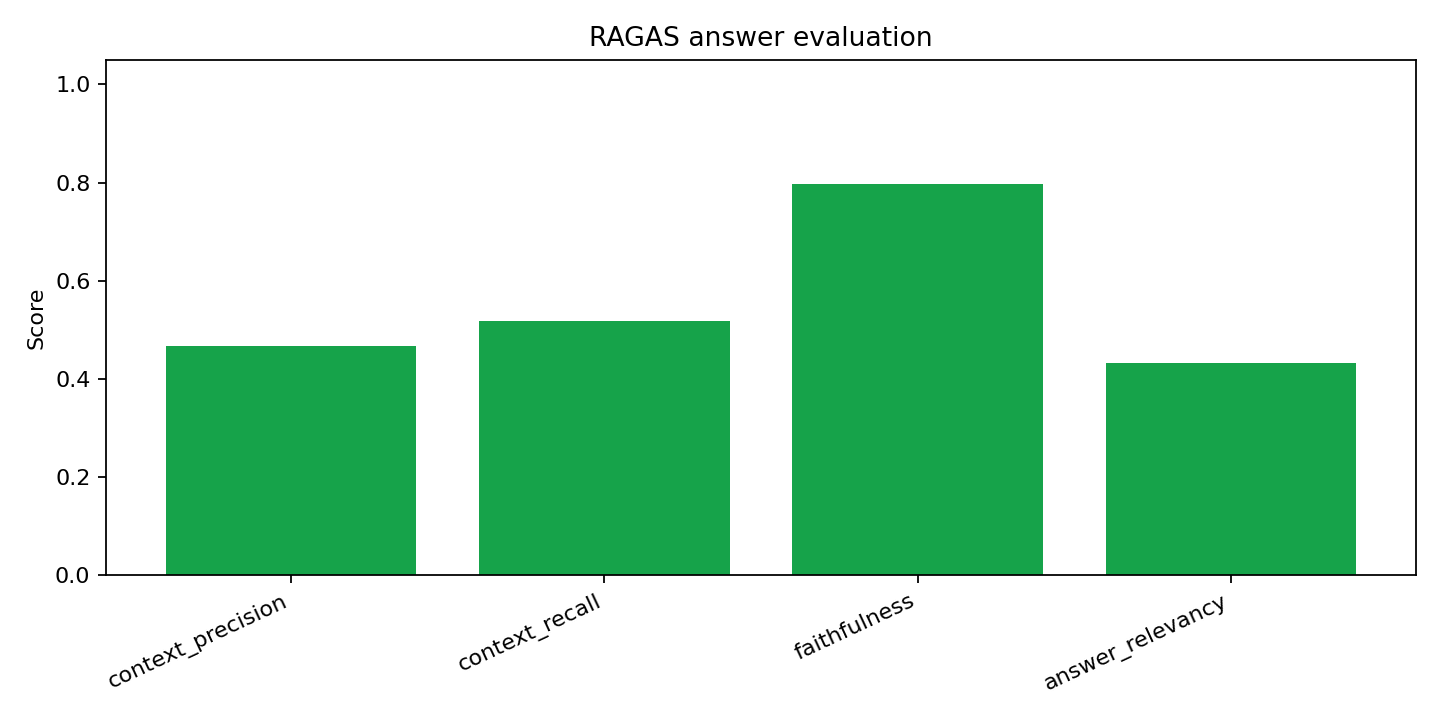

### ragas_per_question_heatmap.png

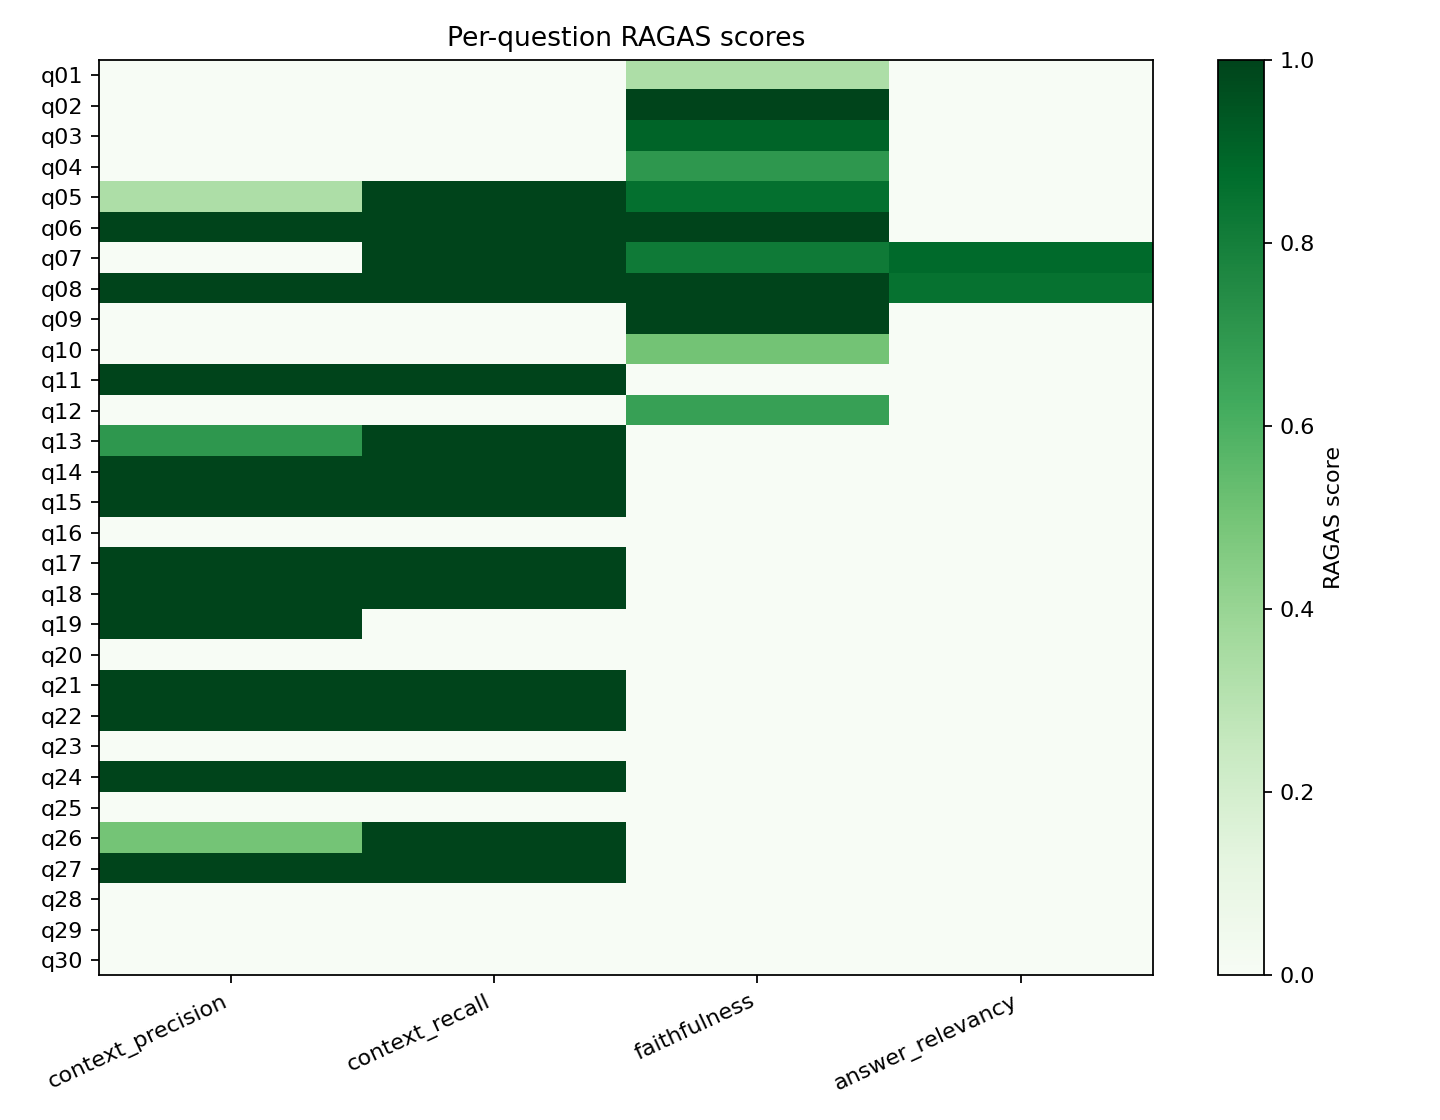

In [7]:

metrics = list(aggregate)
plt.figure(figsize=(9, 4.5))
plt.bar(metrics, [aggregate[metric] for metric in metrics], color="#16a34a")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("RAGAS answer evaluation")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ragas_answer_metrics.png", dpi=160)
plt.close()

details_df = pd.DataFrame(details)
metric_cols = [metric for metric in metrics if metric in details_df]
plt.figure(figsize=(9, 7))
plt.imshow(details_df[metric_cols].fillna(0).values, aspect="auto", cmap="Greens", vmin=0, vmax=1)
plt.colorbar(label="RAGAS score")
plt.xticks(range(len(metric_cols)), metric_cols, rotation=25, ha="right")
plt.yticks(range(len(details_df)), [f"q{idx + 1:02d}" for idx in range(len(details_df))])
plt.title("Per-question RAGAS scores")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ragas_per_question_heatmap.png", dpi=160)
plt.close()

for name in ["ragas_answer_metrics.png", "ragas_per_question_heatmap.png"]:
    display(Markdown(f"### {name}"))
    display(Image(filename=str(FIGURES_DIR / name)))


In [8]:

lines = [
    "# RAGAS Answer Evaluation",
    "",
    f"- Backend: `{ragas_report['backend']}`",
    f"- Cached artifact used: `{ragas_report.get('cached', False)}`",
    f"- Cache reason: `{ragas_report.get('cache_reason') or 'n/a'}`",
    f"- Answers: `{ragas_report['answer_count']}`",
    f"- Retrieval method: `{ragas_report['retrieval_method']}`",
    f"- Model: `{ragas_report['model']}`",
    "",
    "| Metric | Score |",
    "|---|---:|",
]
for metric, value in aggregate.items():
    lines.append(f"| {metric} | {value:.3f} |")
for metric in ragas_report.get("unavailable_metrics", []):
    lines.append(f"| {metric} | unavailable |")
lines.extend(["", "## Figures", "", "- `reports/figures/ragas_answer_metrics.png`", "- `reports/figures/ragas_per_question_heatmap.png`", "", "## Weakest Cases", ""])
details_df["mean_score"] = details_df[metric_cols].mean(axis=1)
for _, row in details_df.sort_values("mean_score").head(5).iterrows():
    question = row.get("user_input") or row.get("question") or ""
    lines.append(f"- {question} - mean={row['mean_score']:.3f}")
RAGAS_EVAL_MD.write_text("\n".join(lines) + "\n", encoding="utf-8")
details_df.sort_values("mean_score").head(8)


,user_input,response,retrieved_contexts,reference,context_precision,context_recall,faithfulness,answer_relevancy,answer_correctness,mean_score
15,Văn bản này hướng dẫn thực hiện các quy định v...,Các văn bản được cung cấp trong ngữ cảnh hướng...,[THÔNG TƯ Hướng dẫn thực hiện Nghị định 56/199...,Văn bản này hướng dẫn thực hiện các quy định v...,0.0,0.0,NaN,NaN,None,0.000000
27,Cty em phai chi bao nhieu % quy luong cho LD-T...,"Dựa trên các văn bản bạn cung cấp, hiện tại **...",[khi xử lý các vấn đề cụ thể ở các ngành liên ...,"Theo quy định, các doanh nghiệp trên địa bàn t...",0.0,0.0,NaN,NaN,None,0.000000
29,Cho em hoi la cai Sở Lao động liên khu no co n...,"Dựa trên các tài liệu được cung cấp, hiện chưa...",[Điều 5. Tiêu chuẩn chung 1. Phẩm chất a) Có...,"Theo quy định, Sở Lao động liên khu có nhiệm v...",0.0,0.0,NaN,NaN,None,0.000000
28,Sở Lao động liên khu có nhiệm vụ gì trong việc...,"Dựa trên các văn bản được cung cấp, nhiệm vụ c...",[Điều 6. Liên đoàn Lao động tỉnh chủ động tổ c...,"Trong phạm vi liên khu, Sở Lao động liên khu c...",0.0,0.0,NaN,NaN,None,0.000000
24,Cho em hoi la UBNN tinh co trach nhiem gi tron...,"Dựa trên các văn bản được cung cấp (Context), ...",[phần tử thuộc loại tệ nạn xã hội (xì...,"Theo quy định, UBND tỉnh có trách nhiệm phối h...",0.0,0.0,NaN,NaN,None,0.000000
19,Quy định về việc tuyển dụng lại đối với công n...,"Dựa trên các tài liệu được cung cấp, hiện **ch...","[Điều 11. Xuất ngũ, kỷ luật 1. Việc giải quyết...","Theo quy định, công nhân bị thải hồi vì phạm k...",0.0,0.0,NaN,NaN,None,0.000000
22,Dieu 33 quy dinh gi ve viec xin thoi viec cua ...,Dựa trên các văn bản được cung cấp (từ [S1] đế...,"[thi tuyển, 15 ngày sau khi tổ chức xét tuyển,...","Theo Điều 33, những công nhân phạm lỗi đang bị...",0.0,0.0,NaN,NaN,None,0.000000
0,Theo quy định tại CHƯƠNG VI thì khi xí nghiệp ...,"Hiện tại, trong nội dung CONTEXT bạn cung cấp ...",[THÔNG TƯ Hướng dẫn thi hành quy chế lao động ...,"Khi giải thể, xí nghiệp phải thực hiện các ngh...",0.0,0.0,0.333333,NaN,None,0.111111
